<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/V19.0_analytical_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

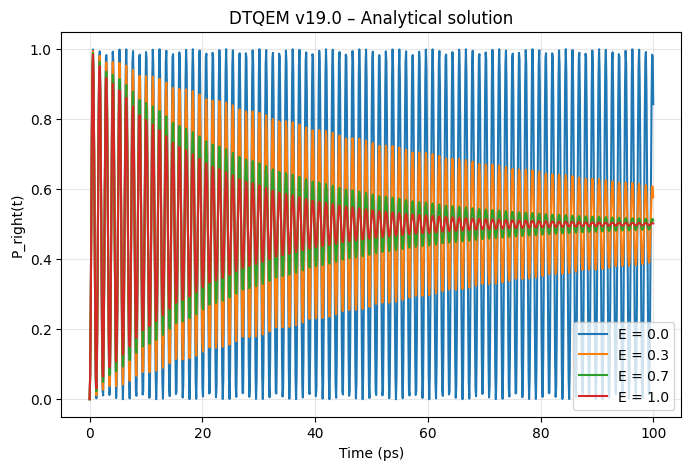

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Analytical solution of DTQEM v19.0
# P(E,t) = 0.5 * [1 - exp(-γ E t) * (cos(ω₀ t) + (γE/ω₀) sin(ω₀ t))]
# ω₀ = Δ/ℏ
# ============================================================

hbar = 1.0545718e-34
eV = 1.60217662e-19
Delta_meV = 3.5
Delta_J = Delta_meV * 1e-3 * eV
omega0 = Delta_J / hbar          # ≈ 5.33e12 rad/s
gamma = 5e10                     # 1/s

def P_right(E, t):
    """Probability to be in the right well (state |1⟩)."""
    gammaE = gamma * E
    exp_factor = np.exp(-gammaE * t)
    cos_term = np.cos(omega0 * t)
    sin_term = np.sin(omega0 * t)
    term = cos_term + (gammaE / omega0) * sin_term
    return 0.5 * (1 - exp_factor * term)

# Example: plot P(t) for different E
t_ps = np.linspace(0, 100, 1000)
t = t_ps * 1e-12

plt.figure(figsize=(8,5))
for E in [0.0, 0.3, 0.7, 1.0]:
    P = P_right(E, t)
    plt.plot(t_ps, P, label=f'E = {E}')
plt.xlabel('Time (ps)')
plt.ylabel('P_right(t)')
plt.title('DTQEM v19.0 – Analytical solution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()